In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal

# Load cleaned data
df = pd.read_csv("cleaned_bearing_data.csv")

# Parse dates
df['subscription_start'] = pd.to_datetime(df['subscription_start'])
df['timestamp_of_fault'] = pd.to_datetime(df['timestamp_of_fault'])

# Compute bearing life
df['operational_days'] = (df['timestamp_of_fault'] - df['subscription_start']).dt.days

# Drop rows with missing required fields
df = df.dropna(subset=['operational_days', 'industry_type', 'machine_type', 'lubrication_method'])

# Clean up 'lubrication_method' column
df['lubrication_method'] = df['lubrication_method'].fillna("Not Available")
df['lubrication_method'] = df['lubrication_method'].replace("", "Not Available")


In [3]:
def summarize_by_group(col):
    grouped = df.groupby(col).agg(
        count=('operational_days', 'count'),
        avg_life=('operational_days', 'mean'),
        median_life=('operational_days', 'median'),
        severity_rate=('bearing_severity_class', lambda x: (x > 0).sum() / len(x))
    ).reset_index()
    return grouped[grouped['count'] >= 10]  # Only show groups with ≥10 samples


In [11]:
industry_summary = summarize_by_group("industry_type")
machine_summary = summarize_by_group("machine_type")
lube_summary = summarize_by_group("lubrication_method")

industry_summary.to_csv("outputs/q3/industry_life_summary.csv", index=False)
machine_summary.to_csv("outputs/q3/machine_life_summary.csv", index=False)
lube_summary.to_csv("outputs/q3/lubrication_life_summary.csv", index=False)



In [7]:
def kruskal_test(col):
    groups = [g['operational_days'].values for _, g in df.groupby(col) if len(g) >= 10]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        return stat, p
    return None, None

print("Kruskal-Wallis p-values:")
for col in ['industry_type', 'machine_type', 'lubrication_method']:
    stat, p = kruskal_test(col)
    print(f"{col}: p = {p:.5f}")


Kruskal-Wallis p-values:
industry_type: p = 0.00000
machine_type: p = 0.00000
lubrication_method: p = 0.00010


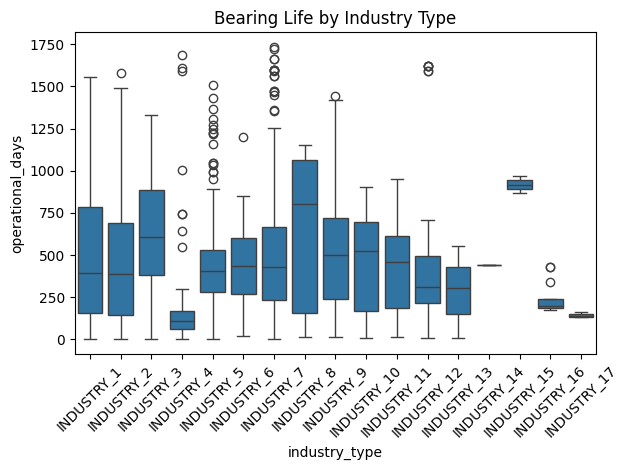

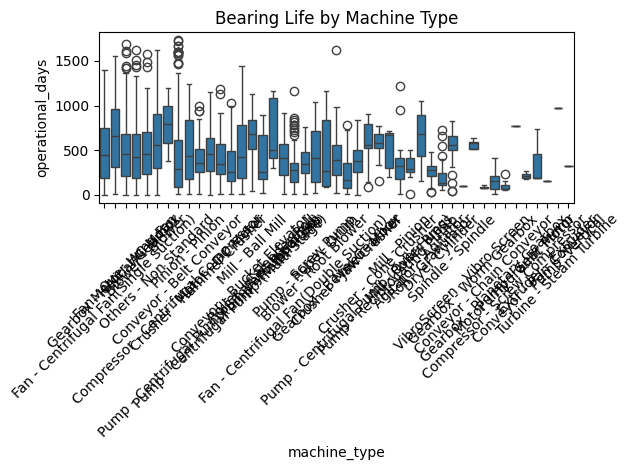

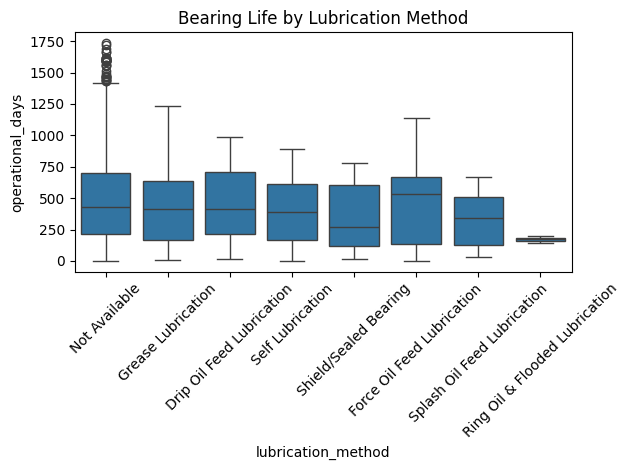

In [9]:
sns.boxplot(data=df, x='industry_type', y='operational_days')
plt.xticks(rotation=45)
plt.title("Bearing Life by Industry Type")
plt.tight_layout()
plt.show()

sns.boxplot(data=df, x='machine_type', y='operational_days')
plt.xticks(rotation=45)
plt.title("Bearing Life by Machine Type")
plt.tight_layout()
plt.show()

sns.boxplot(data=df, x='lubrication_method', y='operational_days')
plt.xticks(rotation=45)
plt.title("Bearing Life by Lubrication Method")
plt.tight_layout()
plt.show()
